In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score
from sklearn import metrics


In [2]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [3]:
train.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [4]:
train.shape

(8522, 12)

In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8522 entries, 0 to 8521
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8522 non-null   object 
 1   Item_Weight                7059 non-null   float64
 2   Item_Fat_Content           8522 non-null   object 
 3   Item_Visibility            8522 non-null   float64
 4   Item_Type                  8522 non-null   object 
 5   Item_MRP                   8522 non-null   float64
 6   Outlet_Identifier          8522 non-null   object 
 7   Outlet_Establishment_Year  8522 non-null   int64  
 8   Outlet_Size                6112 non-null   object 
 9   Outlet_Location_Type       8522 non-null   object 
 10  Outlet_Type                8522 non-null   object 
 11  Item_Outlet_Sales          8522 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.1+ KB


In [6]:
train.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7059.000000,8522.000000,8522.000000,8522.000000,8522.000000
mean,12.857370,0.066135,141.000471,1997.831964,2181.455027
std,4.643728,0.051600,62.274675,8.372247,1706.530835
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.772500,0.026988,93.844250,1987.000000,834.913200
50%,12.600000,0.053935,143.014100,1999.000000,1794.331000
75%,16.850000,0.094594,185.652250,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [7]:
train.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [8]:
train.duplicated().sum()

np.int64(0)

In [9]:
test.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,FDW58,20.750,Low Fat,0.007565,Snack Foods,107.8622,OUT049,1999,Medium,Tier 1,Supermarket Type1
1,FDW14,8.300,reg,0.038428,Dairy,87.3198,OUT017,2007,NaN,Tier 2,Supermarket Type1
2,NCN55,14.600,Low Fat,0.099575,Others,241.7538,OUT010,1998,NaN,Tier 3,Grocery Store
3,FDQ58,7.315,Low Fat,0.015388,Snack Foods,155.0340,OUT017,2007,NaN,Tier 2,Supermarket Type1
4,FDY38,NaN,Regular,0.118599,Dairy,234.2300,OUT027,1985,Medium,Tier 3,Supermarket Type3


In [10]:
test.shape

(5681, 11)

In [11]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5681 entries, 0 to 5680
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            5681 non-null   object 
 1   Item_Weight                4705 non-null   float64
 2   Item_Fat_Content           5681 non-null   object 
 3   Item_Visibility            5681 non-null   float64
 4   Item_Type                  5681 non-null   object 
 5   Item_MRP                   5681 non-null   float64
 6   Outlet_Identifier          5681 non-null   object 
 7   Outlet_Establishment_Year  5681 non-null   int64  
 8   Outlet_Size                4075 non-null   object 
 9   Outlet_Location_Type       5681 non-null   object 
 10  Outlet_Type                5681 non-null   object 
dtypes: float64(3), int64(1), object(7)
memory usage: 488.3+ KB


In [12]:
test.isnull().sum()

Item_Identifier                 0
Item_Weight                   976
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  1606
Outlet_Location_Type            0
Outlet_Type                     0
dtype: int64

In [13]:
test.duplicated().sum()

np.int64(0)

# Filling Missing Value

In [14]:
# Numerical -> mean , Item_Weight  
# Categorical-> mode, Outlet_Size

In [15]:
train['Item_Weight'].fillna(train['Item_Weight'].mean(), inplace=True)
test['Item_Weight'].fillna(test['Item_Weight'].mean(), inplace=True)

In [16]:
train.isnull().sum()

Item_Identifier                 0
Item_Weight                     0
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [17]:
train['Outlet_Size'].fillna(train['Outlet_Size'].mode(), inplace=True)
test['Outlet_Size'].fillna(test['Outlet_Size'].mode(), inplace=True)

In [18]:
train.isnull().sum()

Item_Identifier                 0
Item_Weight                     0
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [19]:
train['Outlet_Size'].unique()

array(['Medium', nan, 'High', 'Small'], dtype=object)

In [20]:
train['Outlet_Size'].mode()

0    Medium
Name: Outlet_Size, dtype: object

In [21]:
train['Outlet_Type'].unique()

array(['Supermarket Type1', 'Supermarket Type2', 'Grocery Store',
       'Supermarket Type3'], dtype=object)

In [22]:
mode_of_outlet_size = train.pivot_table(values='Outlet_Size', columns = 'Outlet_Type', aggfunc = lambda x : x.mode()[0])

In [23]:
mode_of_outlet_size

Outlet_Type,Grocery Store,Supermarket Type1,Supermarket Type2,Supermarket Type3
Outlet_Size,Small,Small,Medium,Medium


In [24]:
missing_value = train['Outlet_Size'].isnull()

In [25]:
missing_value.value_counts()

Outlet_Size
False    6112
True     2410
Name: count, dtype: int64

# Exploratory Data Analysis

In [26]:
import dtale


In [27]:
import dtale.app as dtale_app
dtale_app.USE_COLAB = True
dtale.show(train)

In [28]:
numeric_cols = train.select_dtypes(include=['float64', 'int64']).columns.tolist()
numeric_cols

['Item_Weight',
 'Item_Visibility',
 'Item_MRP',
 'Outlet_Establishment_Year',
 'Item_Outlet_Sales']

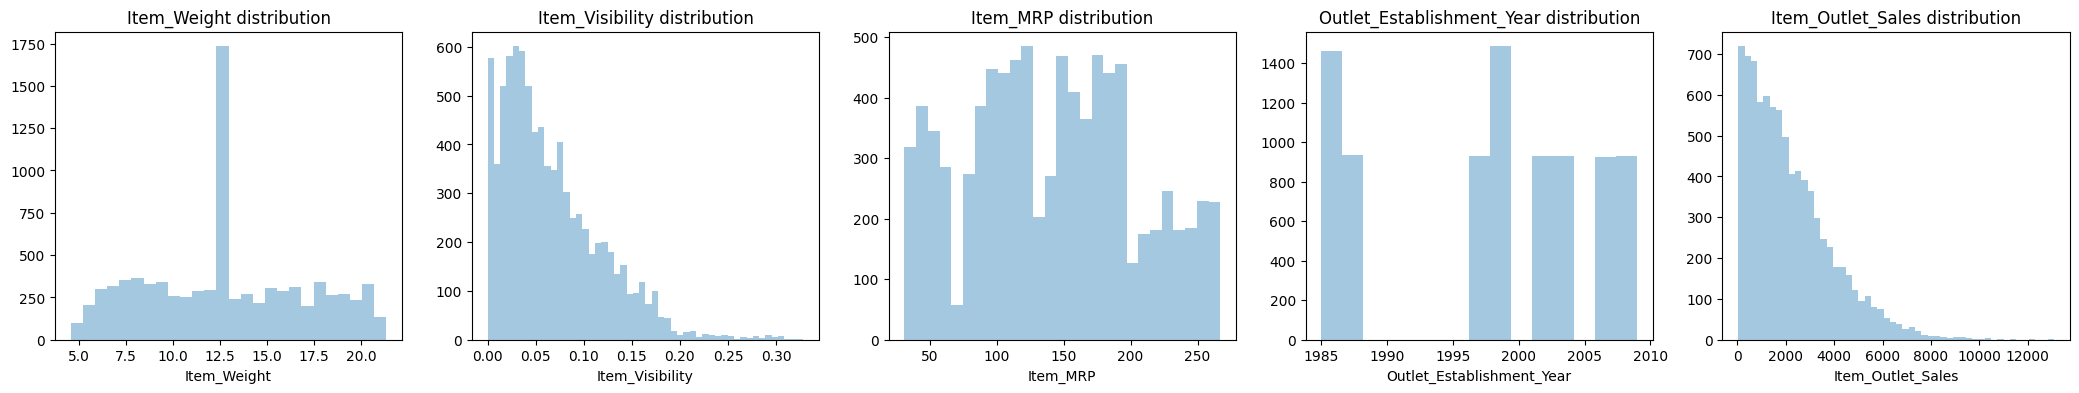

In [29]:
_, ax = plt.subplots(nrows=1, ncols=5, figsize=(26, 4))

for index, col in enumerate(numeric_cols):
    sns.distplot(train[col], kde=False, ax=ax[index])
    ax[index].set_title(f'{col} distribution')

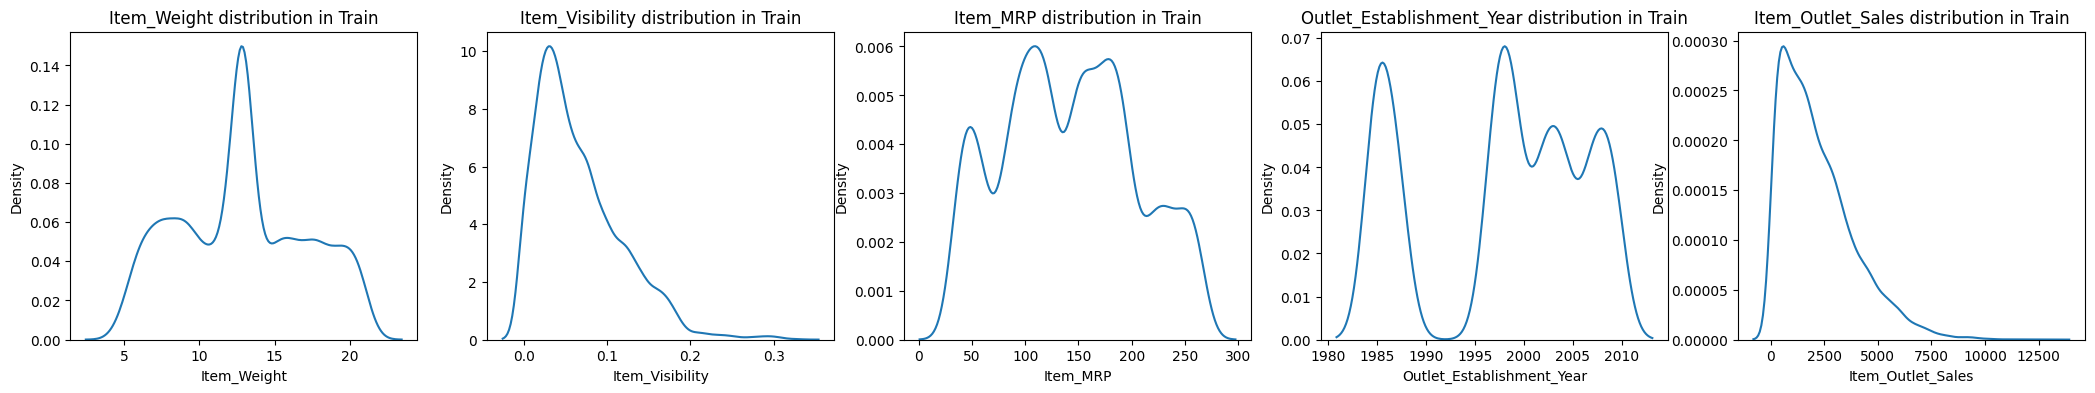

In [30]:
_, ax = plt.subplots(nrows=1, ncols=5, figsize=(26, 4))

for index, col in enumerate(numeric_cols):
    sns.kdeplot(data=train, x=col, ax=ax[index])
    ax[index].set_title(f'{col} distribution in Train')

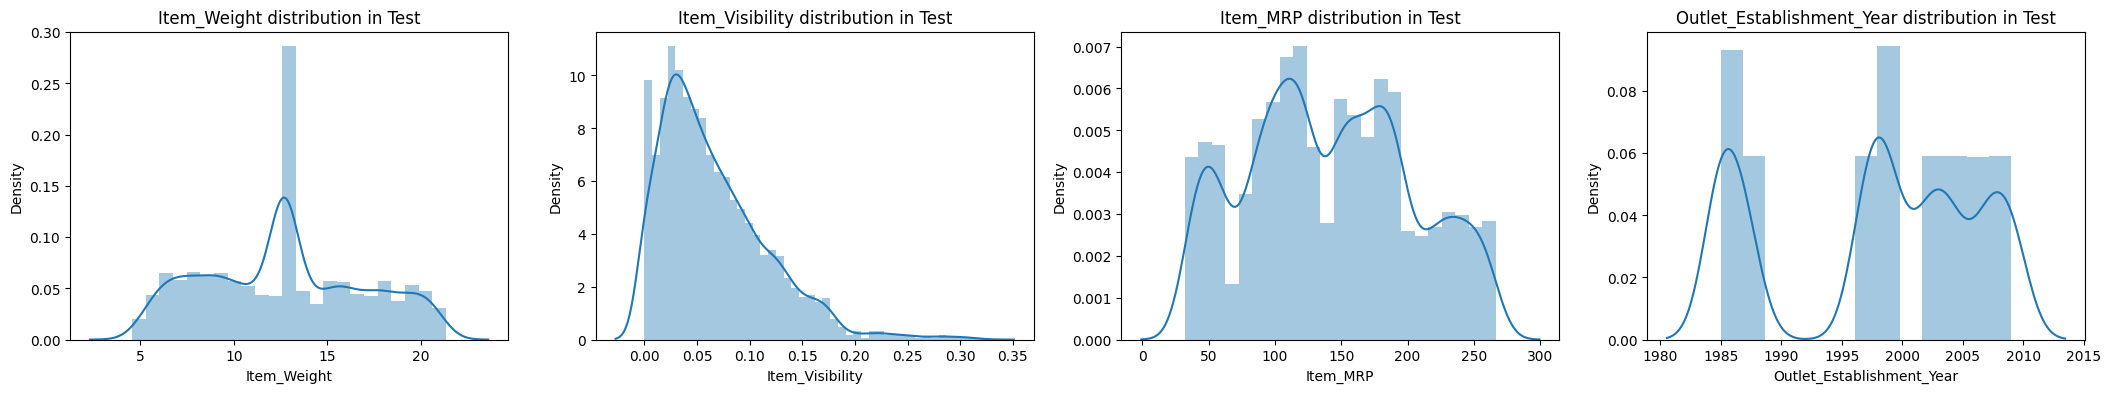

In [31]:
_, ax = plt.subplots(nrows=1, ncols=4, figsize=(26, 4))

for index, col in enumerate(['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Establishment_Year']):
    sns.distplot(test[col], kde=True, ax=ax[index])
    ax[index].set_title(f'{col} distribution in Test')

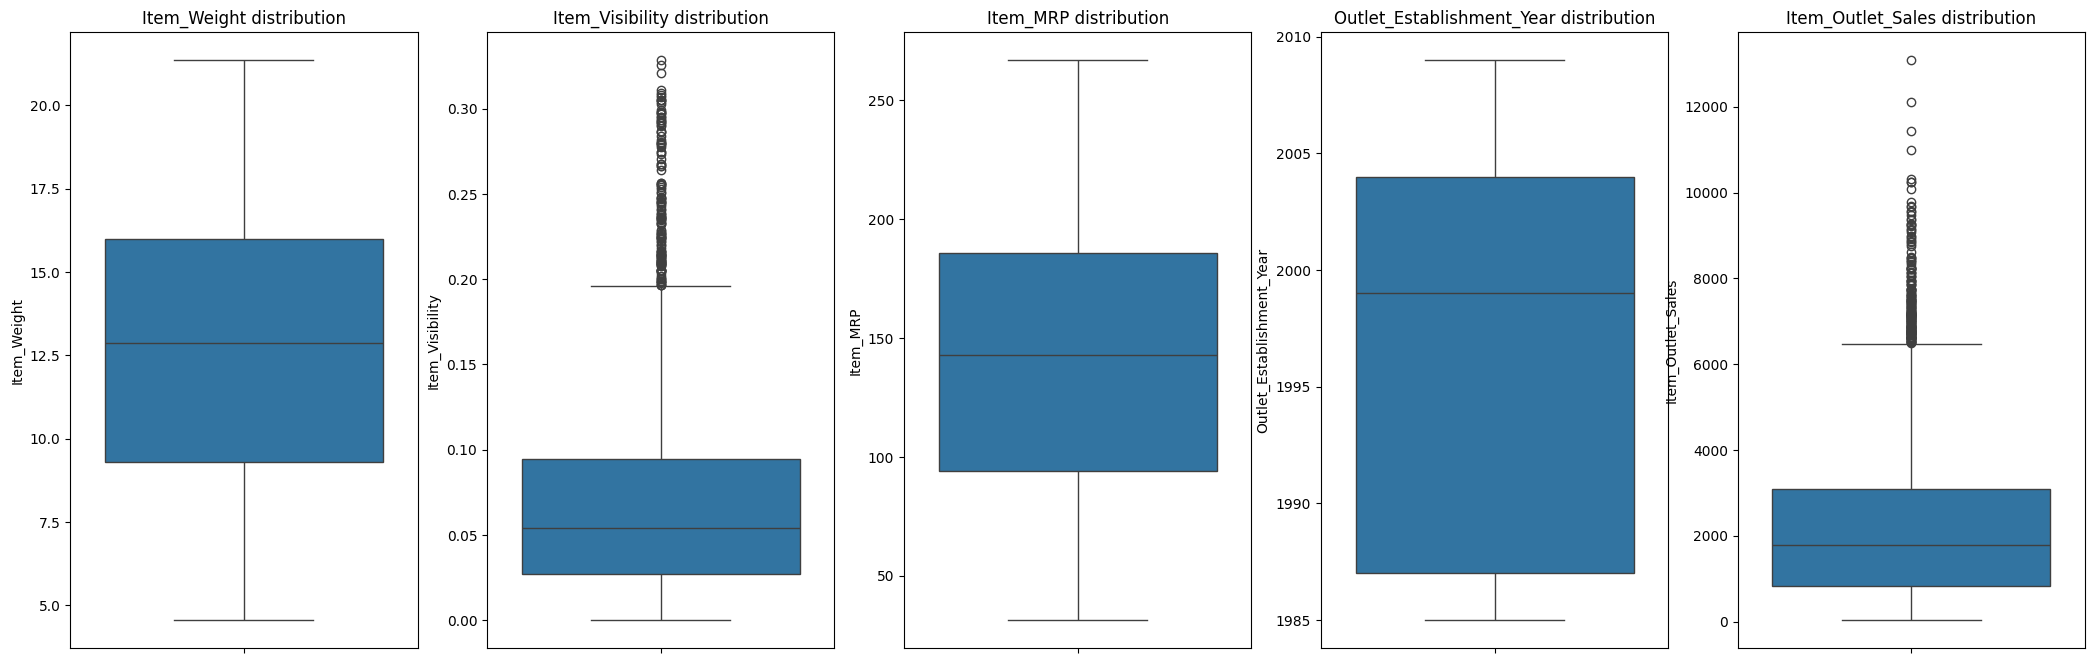

In [32]:
_, ax = plt.subplots(nrows=1, ncols=5, figsize=(26,8))
for index, col in enumerate(numeric_cols):
    sns.boxplot(data=train, y=col, ax=ax[index])
    ax[index].set_title(f'{col} distribution')

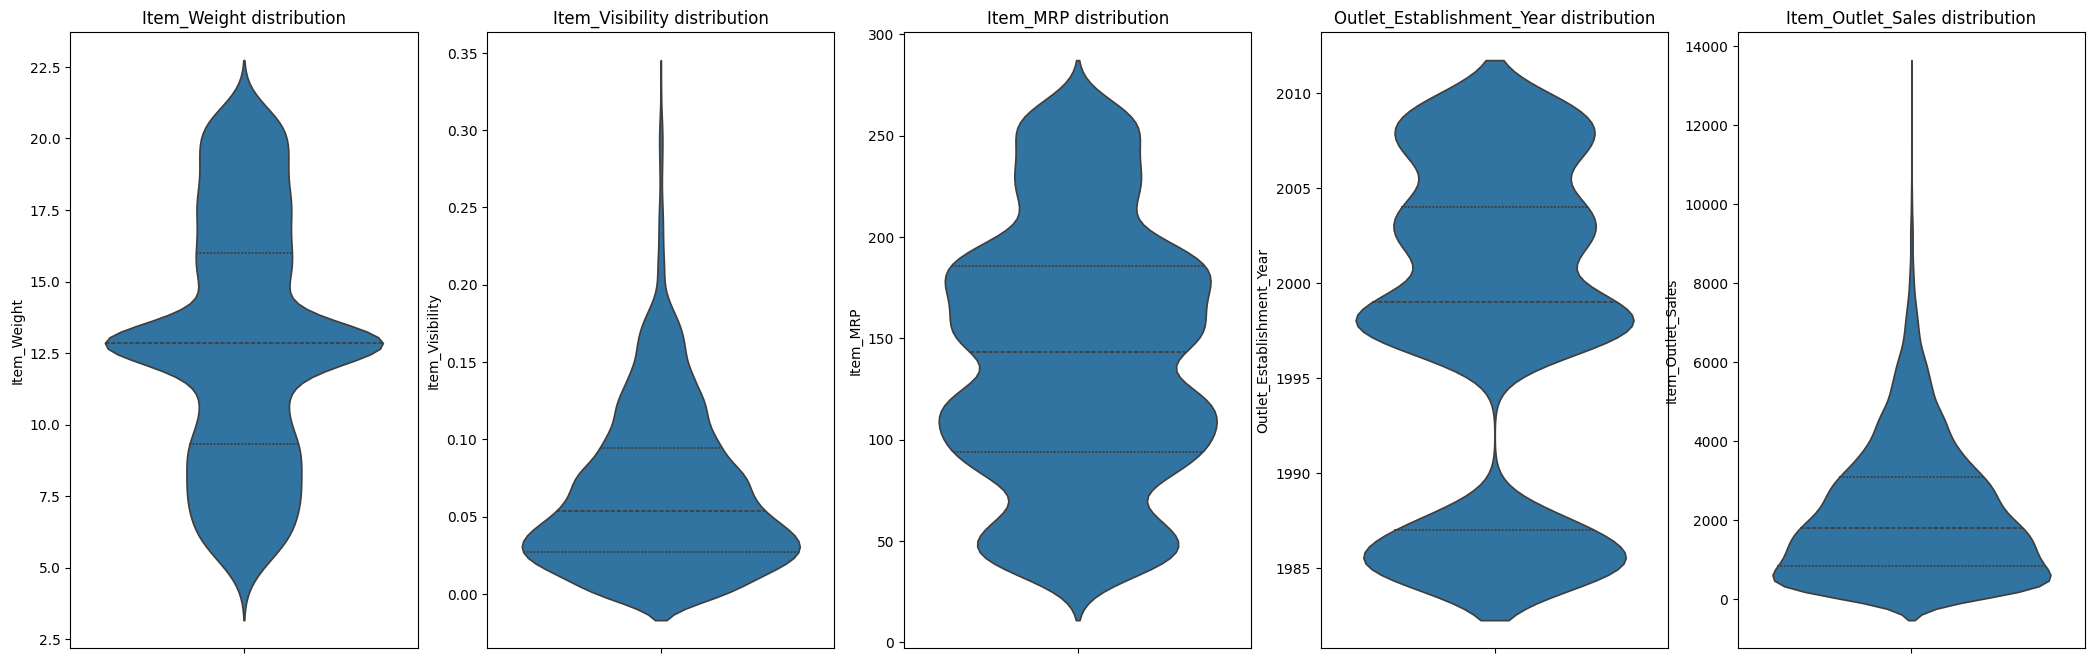

In [33]:
_, ax = plt.subplots(nrows=1, ncols=5, figsize=(26,8))
for index, col in enumerate(numeric_cols):
    sns.violinplot(data=train, y=col, ax=ax[index], inner='quartile')
    ax[index].set_title(f'{col} distribution')

In [34]:
categorical_cols = train.select_dtypes(include=['object']).columns.tolist()
categorical_cols

['Item_Identifier',
 'Item_Fat_Content',
 'Item_Type',
 'Outlet_Identifier',
 'Outlet_Size',
 'Outlet_Location_Type',
 'Outlet_Type']

In [35]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
Item_Weight,8522.0,12.857370,4.226319,4.555,9.310000,12.857370,16.000000,21.350000
Item_Visibility,8522.0,0.066135,0.051600,0.000,0.026988,0.053935,0.094594,0.328391
Item_MRP,8522.0,141.000471,62.274675,31.290,93.844250,143.014100,185.652250,266.888400
Outlet_Establishment_Year,8522.0,1997.831964,8.372247,1985.000,1987.000000,1999.000000,2004.000000,2009.000000
Item_Outlet_Sales,8522.0,2181.455027,1706.530835,33.290,834.913200,1794.331000,3101.296400,13086.964800


In [36]:
train.columns

Index(['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility',
       'Item_Type', 'Item_MRP', 'Outlet_Identifier',
       'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type',
       'Outlet_Type', 'Item_Outlet_Sales'],
      dtype='object')

In [37]:
train.select_dtypes(include='object').columns

Index(['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Outlet_Identifier',
       'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type'],
      dtype='object')

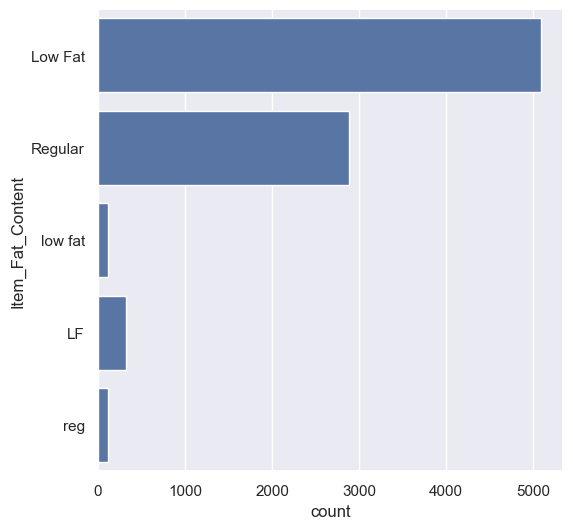

In [38]:
# Item_Fat_Content Count
sns.set()
plt.figure(figsize=(6,6))
sns.countplot(train['Item_Fat_Content'])
plt.show()

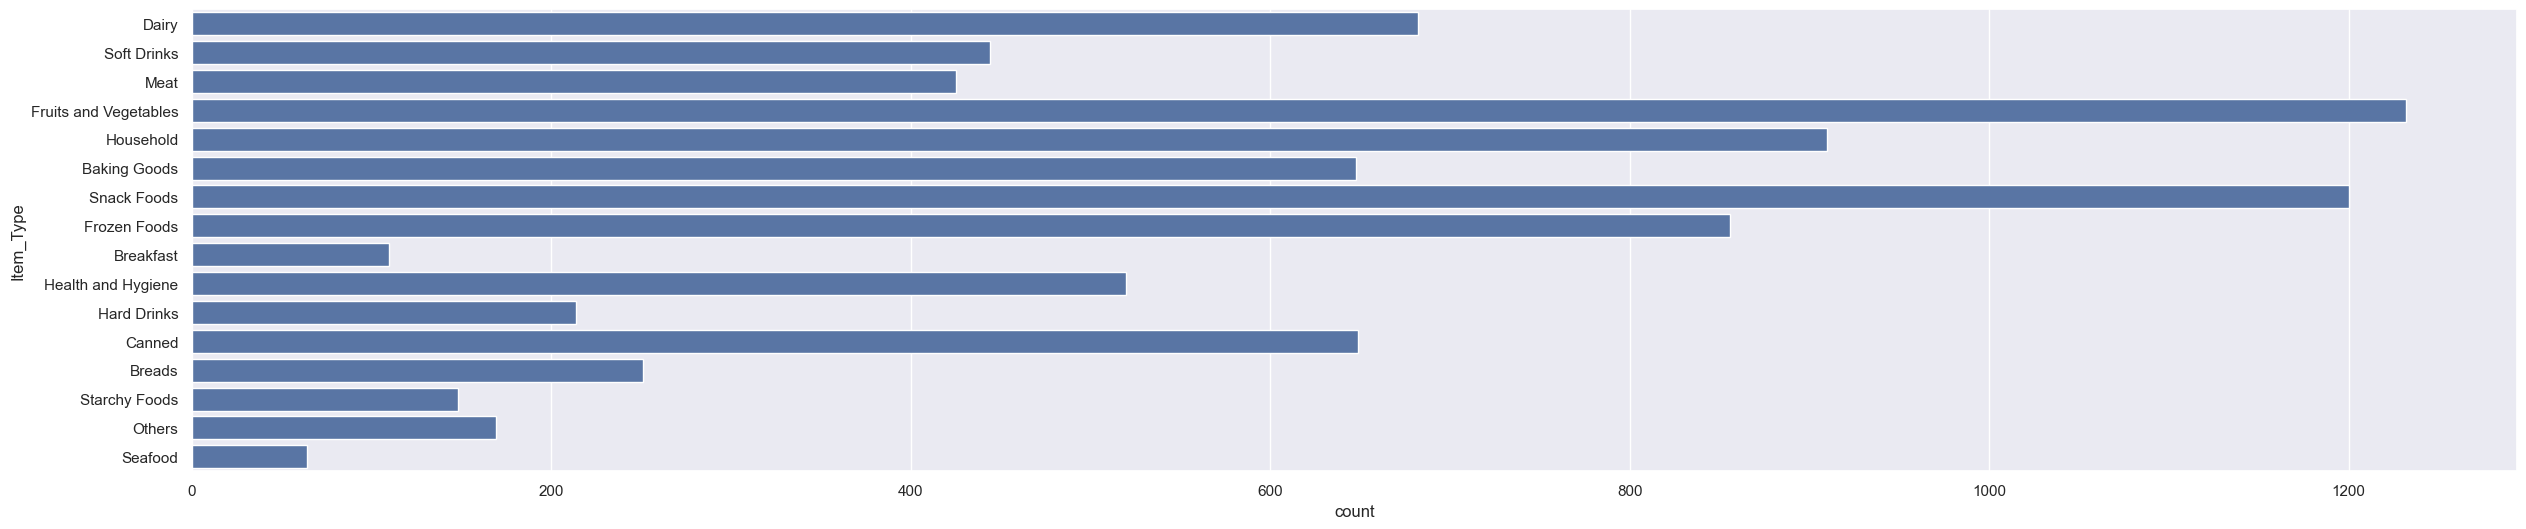

In [39]:
# Item_Type Count
sns.set()
plt.figure(figsize=(30,6))
sns.countplot(train['Item_Type'])
plt.show()

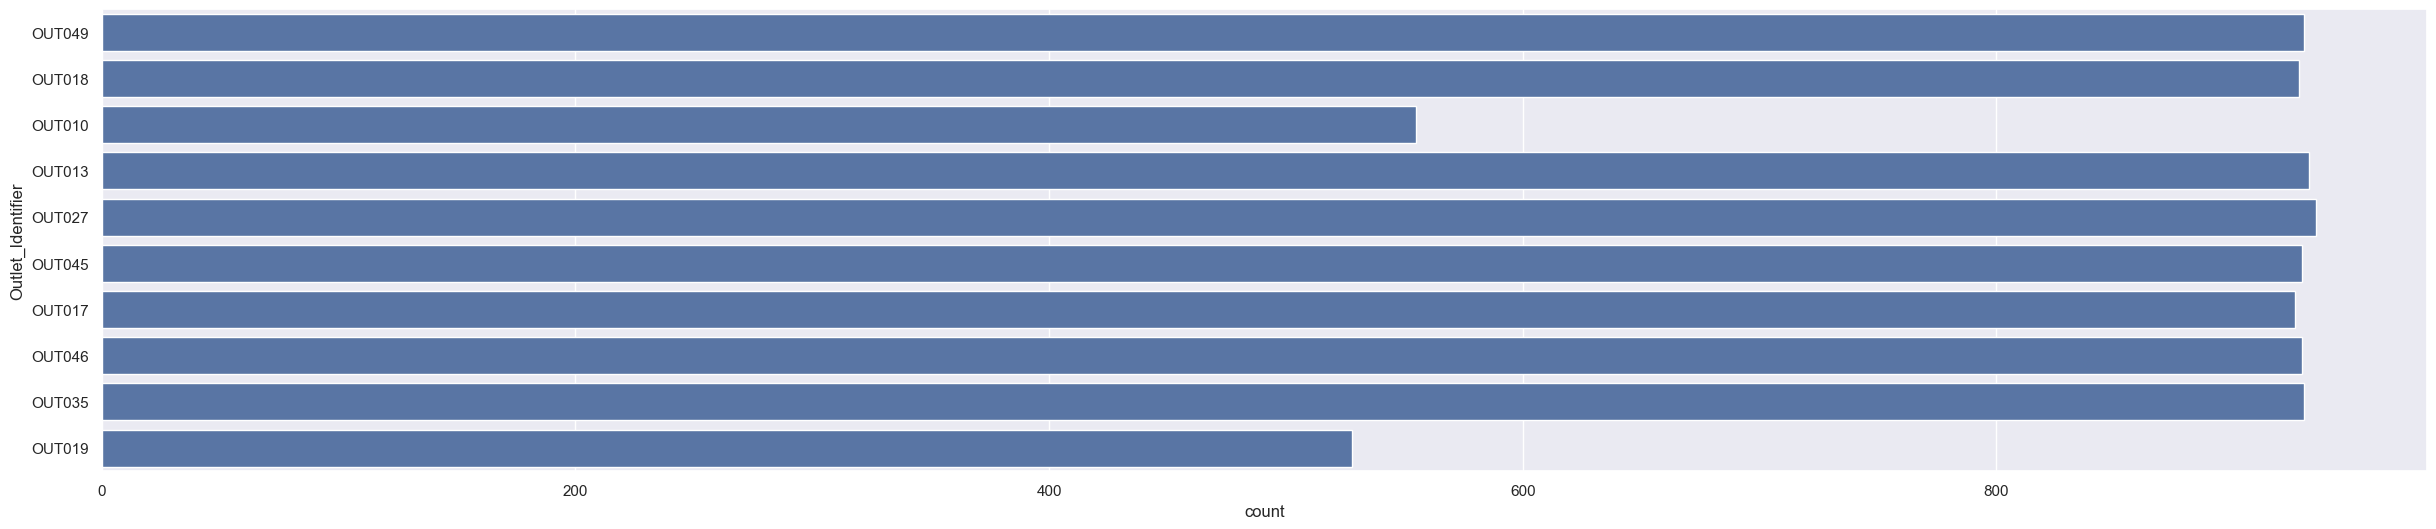

In [40]:
# Outlet_Identifier Count
sns.set()
plt.figure(figsize=(30,6))
sns.countplot(train['Outlet_Identifier'])
plt.show()

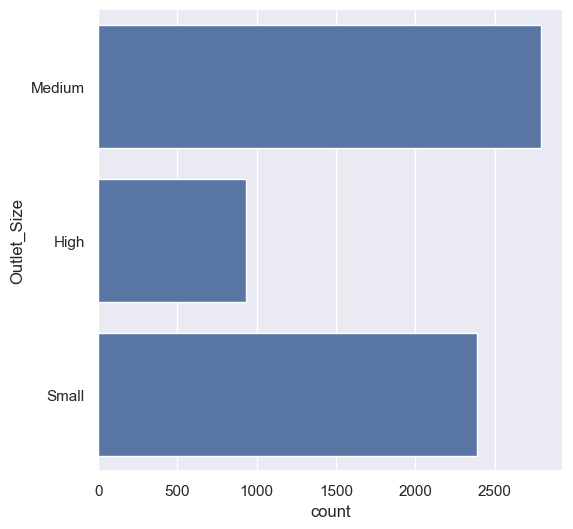

In [41]:
# Outlet_Size Count
sns.set()
plt.figure(figsize=(6,6))
sns.countplot(train['Outlet_Size'])
plt.show()

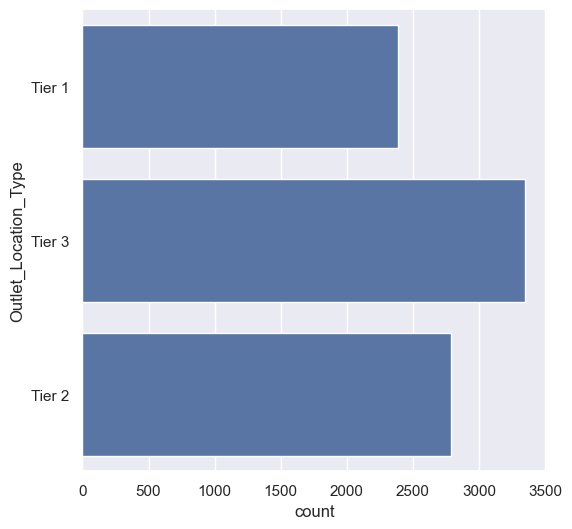

In [42]:
# Outlet_Location_Type Count
sns.set()
plt.figure(figsize=(6,6))
sns.countplot(train['Outlet_Location_Type'])
plt.show()

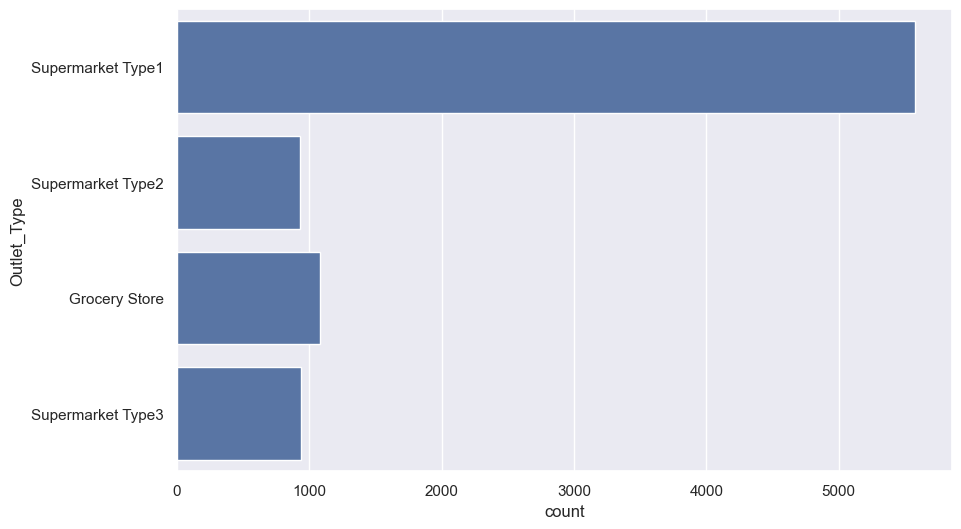

In [43]:
# Outlet_Type Count
sns.set()
plt.figure(figsize=(10,6))
sns.countplot(train['Outlet_Type'])
plt.show()

In [44]:
train.replace({'Item_Fat_Content': {'low fat': 'Low Fat', 'LF': 'Low Fat', 'reg':'Regular'}}, inplace=True)

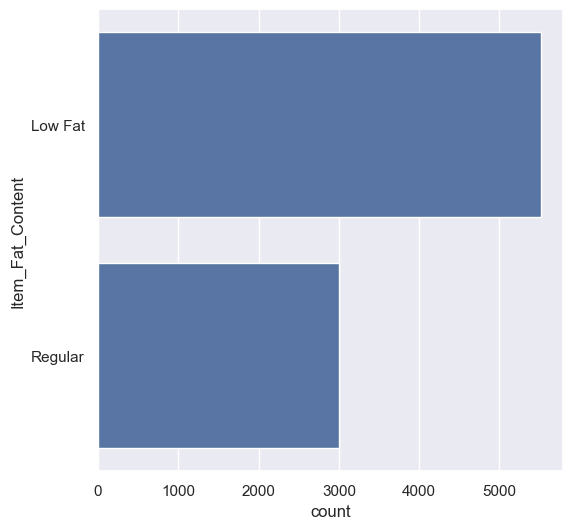

In [45]:
# Item_Fat_Content Count
sns.set()
plt.figure(figsize=(6,6))
sns.countplot(train['Item_Fat_Content'])
plt.show()

In [46]:
train.select_dtypes(include='object').columns

Index(['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Outlet_Identifier',
       'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type'],
      dtype='object')

# Bivariate Analysis

In [47]:
target = "Item_Outlet_Sales"

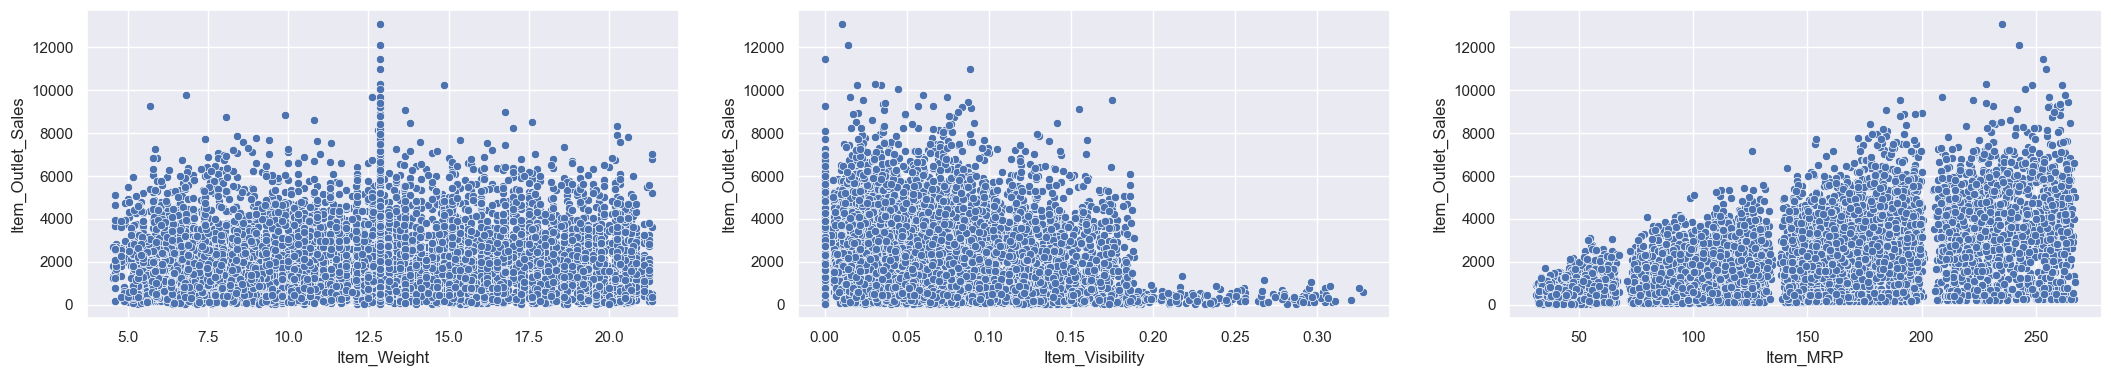

In [48]:
_, ax = plt.subplots(nrows=1, ncols=3, figsize=(26, 4))

for index, col in enumerate(['Item_Weight', 'Item_Visibility', 'Item_MRP']):
    sns.scatterplot(data=train,x=col, y=target, ax=ax[index])
    #ax[index].set_title(f'{col} distribution')

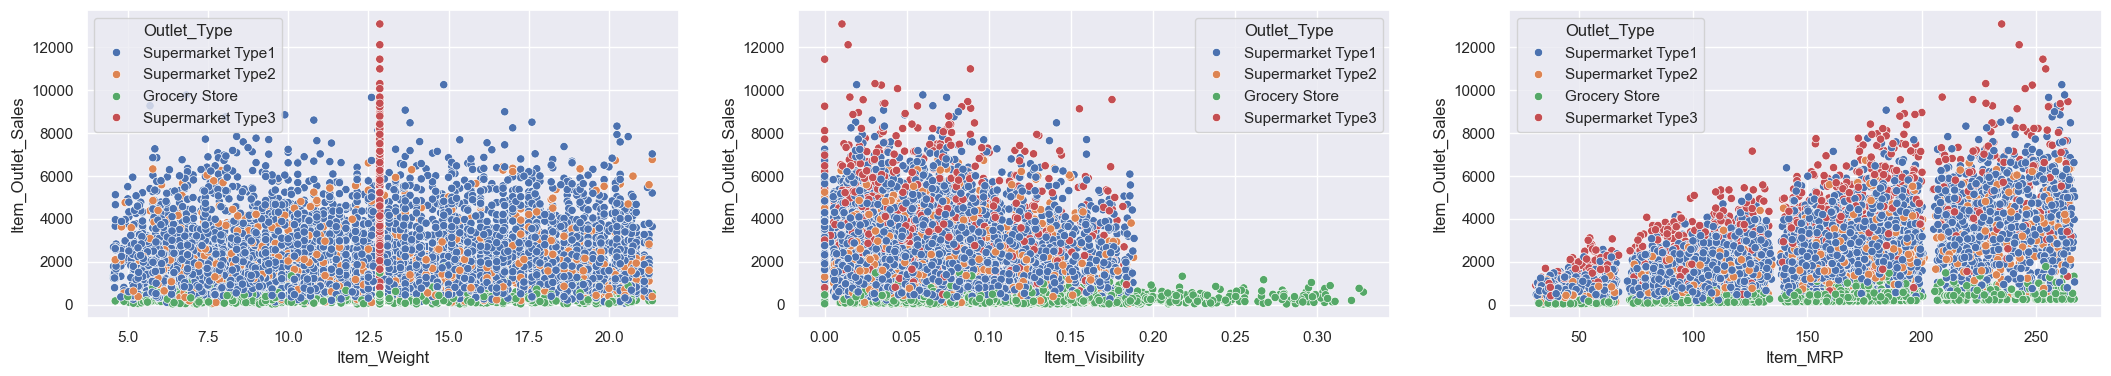

In [49]:
_, ax = plt.subplots(nrows=1, ncols=3, figsize=(26, 4))

for index, col in enumerate(['Item_Weight', 'Item_Visibility', 'Item_MRP']):
    sns.scatterplot(data=train,x=col, y=target, ax=ax[index], hue='Outlet_Type')

<Axes: >

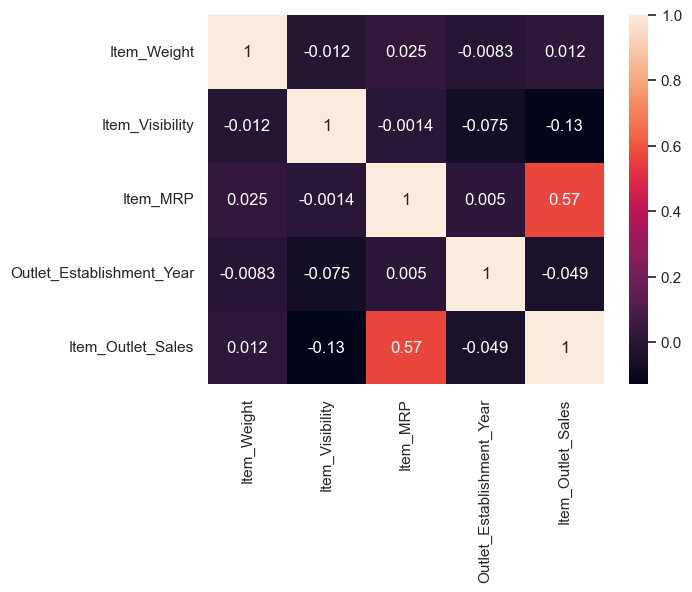

In [50]:
sns.heatmap(train.select_dtypes(include=['number']).corr(), annot=True)

<Axes: xlabel='Outlet_Size', ylabel='Item_Outlet_Sales'>

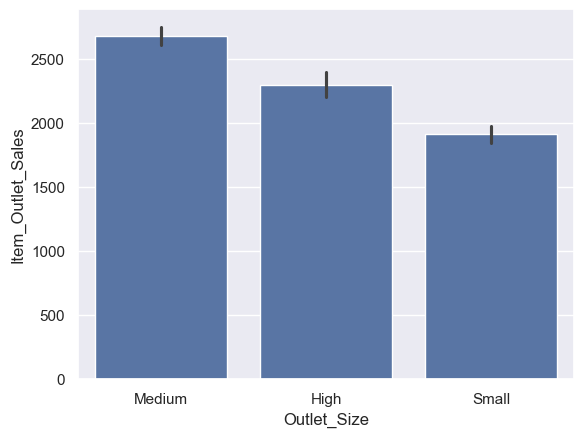

In [51]:
sns.barplot(data=train, x='Outlet_Size', y=target)

In [52]:
train.Outlet_Establishment_Year

0       1999
1       2009
2       1999
3       1998
4       1987
        ... 
8517    1997
8518    1987
8519    2002
8520    2004
8521    2009
Name: Outlet_Establishment_Year, Length: 8522, dtype: int64

<Axes: title={'center': 'Feature-correlation (pearson)'}>

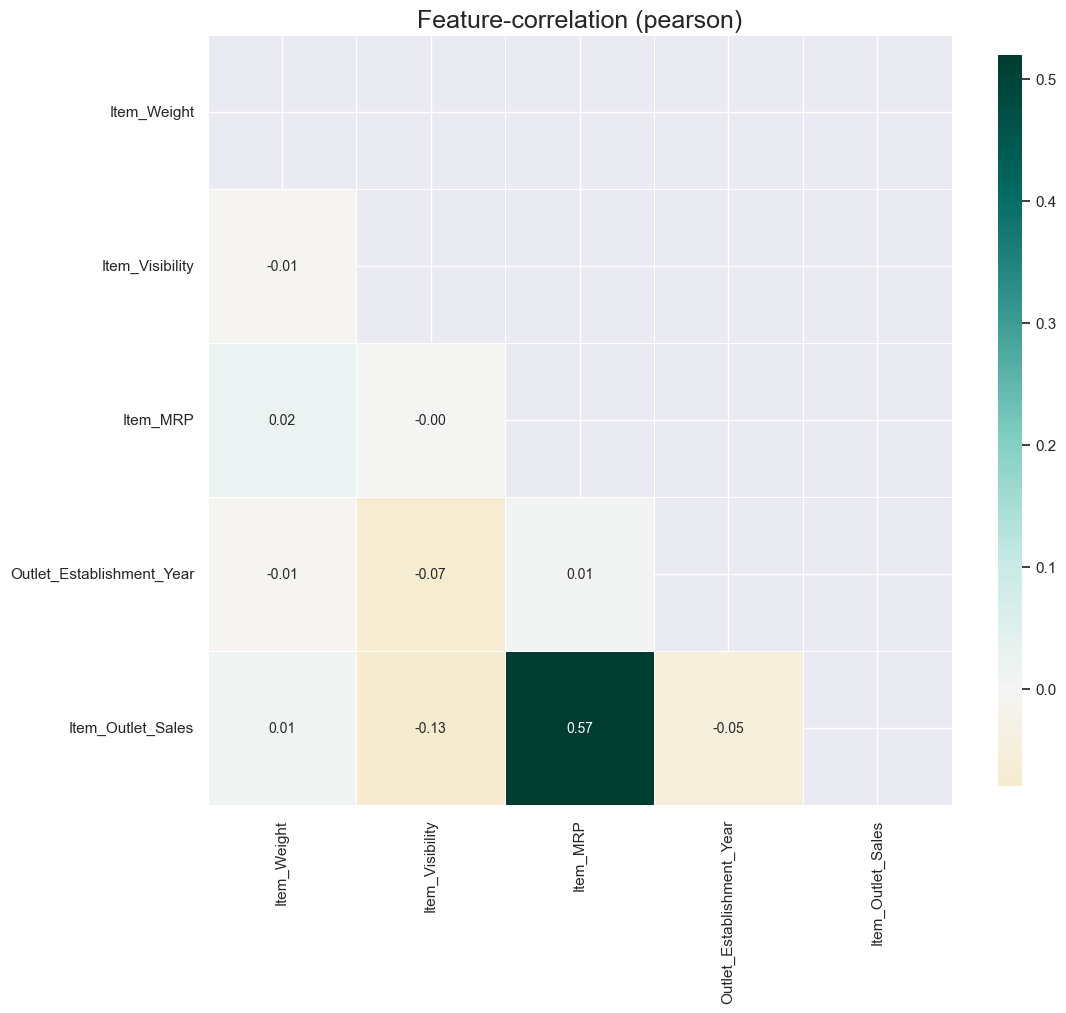

In [53]:
import klib
klib.corr_plot(train)  # Show correlations

In [54]:
klib.corr_mat(train)  # Show correlations

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
Item_Weight,1.00,-0.01,0.02,-0.01,0.01
Item_Visibility,-0.01,1.00,-0.00,-0.07,-0.13
Item_MRP,0.02,-0.00,1.00,0.01,0.57
Outlet_Establishment_Year,-0.01,-0.07,0.01,1.00,-0.05
Item_Outlet_Sales,0.01,-0.13,0.57,-0.05,1.00


<Axes: xlabel='Item_Outlet_Sales', ylabel='Density'>

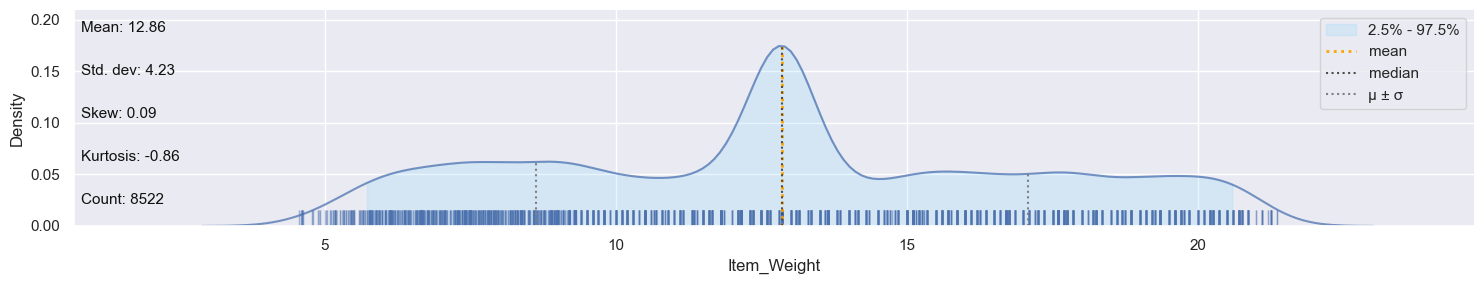

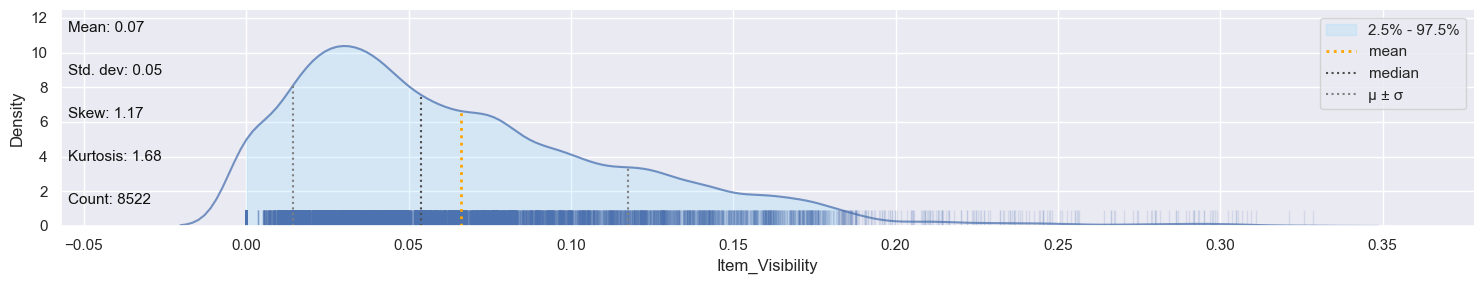

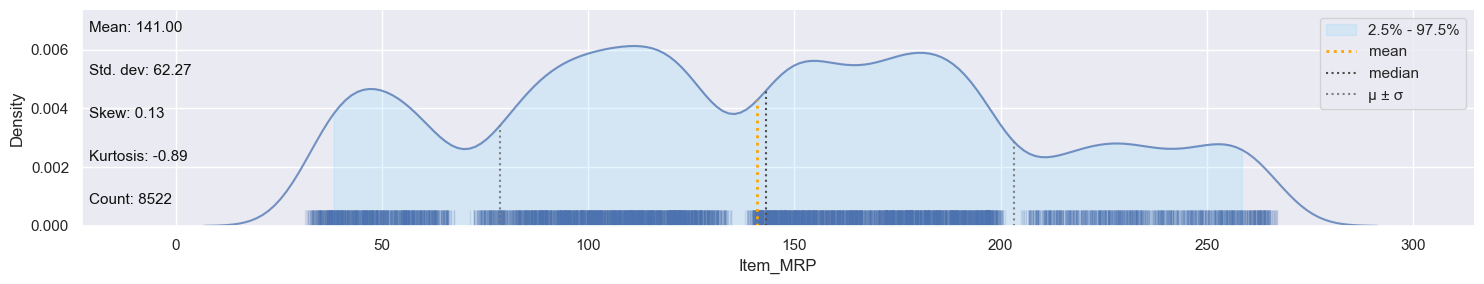

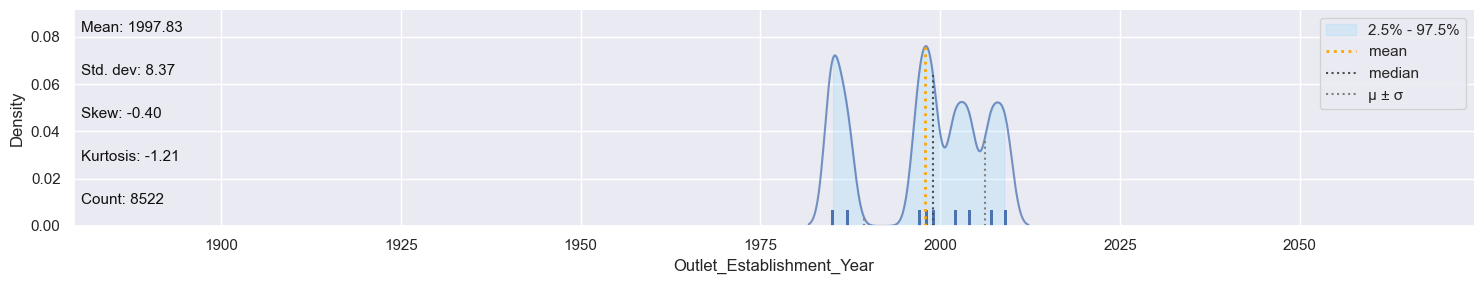

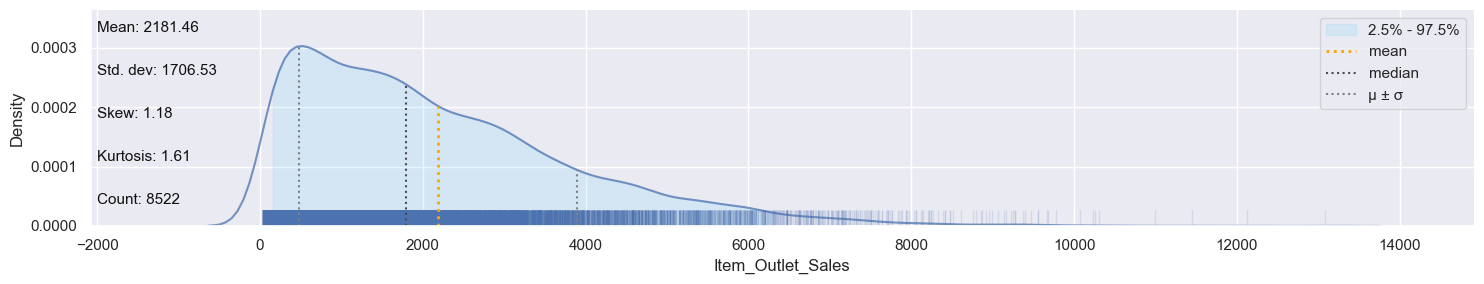

In [55]:
klib.dist_plot(train)  # Visualize distributions

# Data Cleaning

In [56]:
klib.data_cleaning(train)

Shape of cleaned data: (8522, 12) - Remaining NAs: 2410


Dropped rows: 0
     of which 0 duplicates. (Rows (first 150 shown): [])

Dropped columns: 0
     of which 0 single valued.     Columns: []
Dropped missing values: 0
Reduced memory by at least: 0.52 MB (-66.67%)



,item_identifier,item_weight,item_fat_content,item_visibility,item_type,item_mrp,outlet_identifier,outlet_establishment_year,outlet_size,outlet_location_type,outlet_type,item_outlet_sales
0,FDA15,9.300000,Low Fat,0.016047,Dairy,249.809204,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.137939
1,DRC01,5.920000,Regular,0.019278,Soft Drinks,48.269199,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.422791
2,FDN15,17.500000,Low Fat,0.016760,Meat,141.617996,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.270020
3,FDX07,19.200001,Regular,0.000000,Fruits and Vegetables,182.095001,OUT010,1998,NaN,Tier 3,Grocery Store,732.380005
4,NCD19,8.930000,Low Fat,0.000000,Household,53.861401,OUT013,1987,High,Tier 3,Supermarket Type1,994.705200
...,...,...,...,...,...,...,...,...,...,...,...,...
8517,FDF53,20.750000,Regular,0.083607,Frozen Foods,178.831802,OUT046,1997,Small,Tier 1,Supermarket Type1,3608.635986
8518,FDF22,6.865000,Low Fat,0.056783,Snack Foods,214.521805,OUT013,1987,High,Tier 3,Supermarket Type1,2778.383301
8519,FDS36,8.380000,Regular,0.046982,Baking Goods,108.156998,OUT045,2002,NaN,Tier 2,Supermarket Type1,549.284973
8520,NCJ29,10.600000,Low Fat,0.035186,Health and Hygiene,85.122398,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.113647


# Feature Engineering

Upper limit:  0.19600398725000004
Lower limit:  -0.07442171675000006


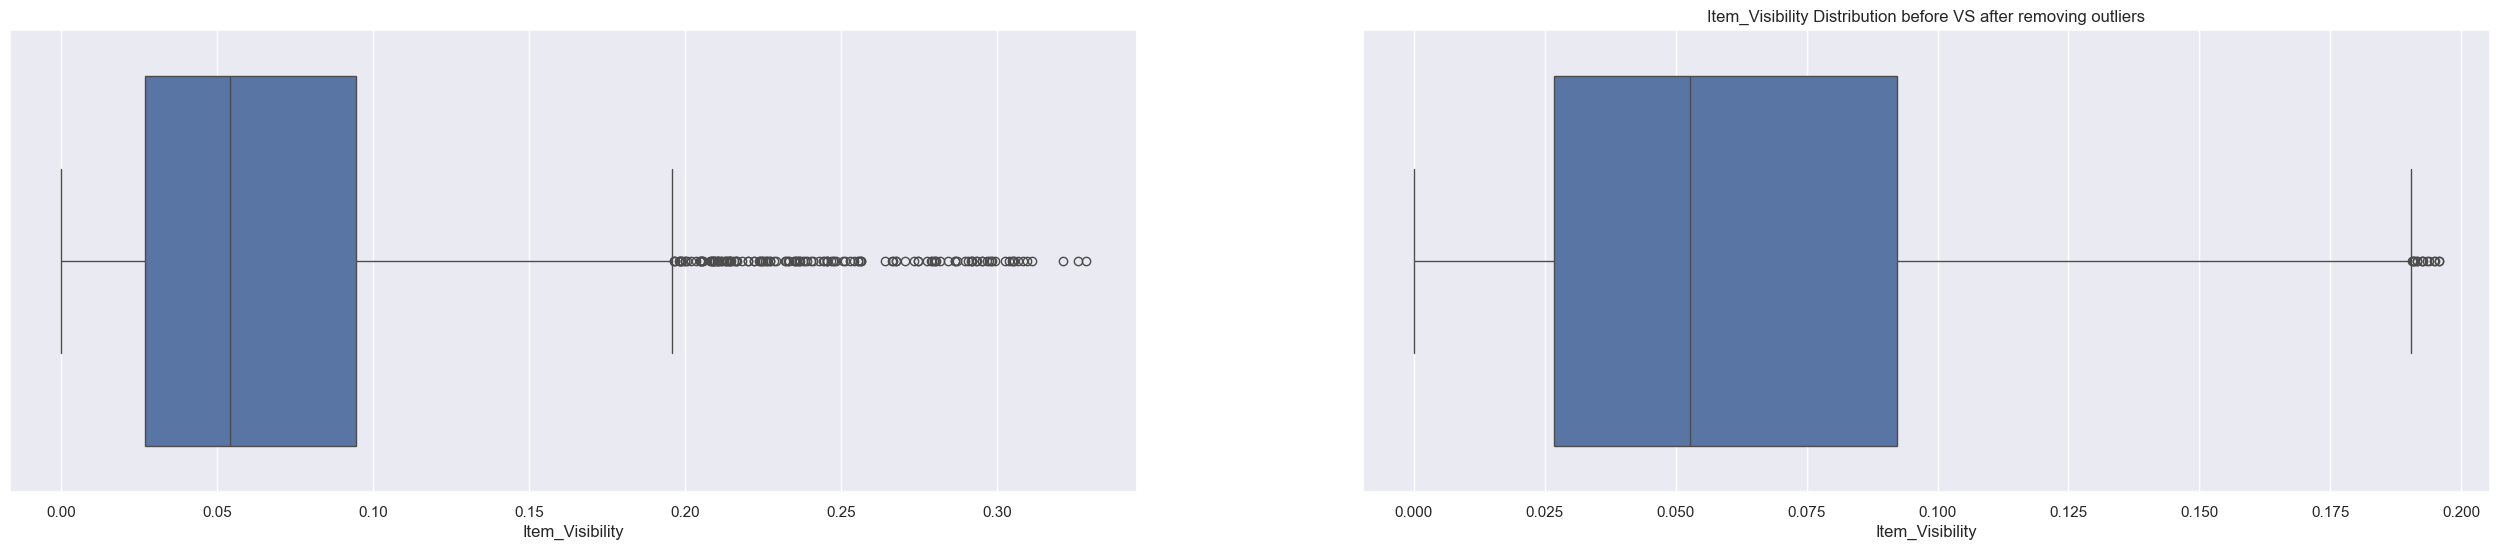

In [57]:
# function to detect outliers using the IQR method

def detect_outliers(df, feature):
    Q1  = df[feature].quantile(0.25)
    Q3  = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    
    upper_limit = Q3 + 1.5 * IQR
    lower_limit = Q1 - 1.5 * IQR
    return upper_limit, lower_limit

upper, lower = detect_outliers(train, "Item_Visibility")
print("Upper limit: ", upper)
print("Lower limit: ", lower)

_, ax = plt.subplots(nrows=1, ncols=2, figsize=(32, 6))
sns.boxplot(x=train['Item_Visibility'], ax=ax[0])

# removing outliers using the above function
train = train[(train['Item_Visibility'] > lower) & (train['Item_Visibility'] < upper)] #train
test = test[(test['Item_Visibility'] > lower) & (test['Item_Visibility'] < upper)]     #test

sns.boxplot(x=train['Item_Visibility'], ax=ax[1])
plt.title('Item_Visibility Distribution before VS after removing outliers')
plt.show()

Upper limit:  6499.2067
Lower limit:  -2499.7460999999994


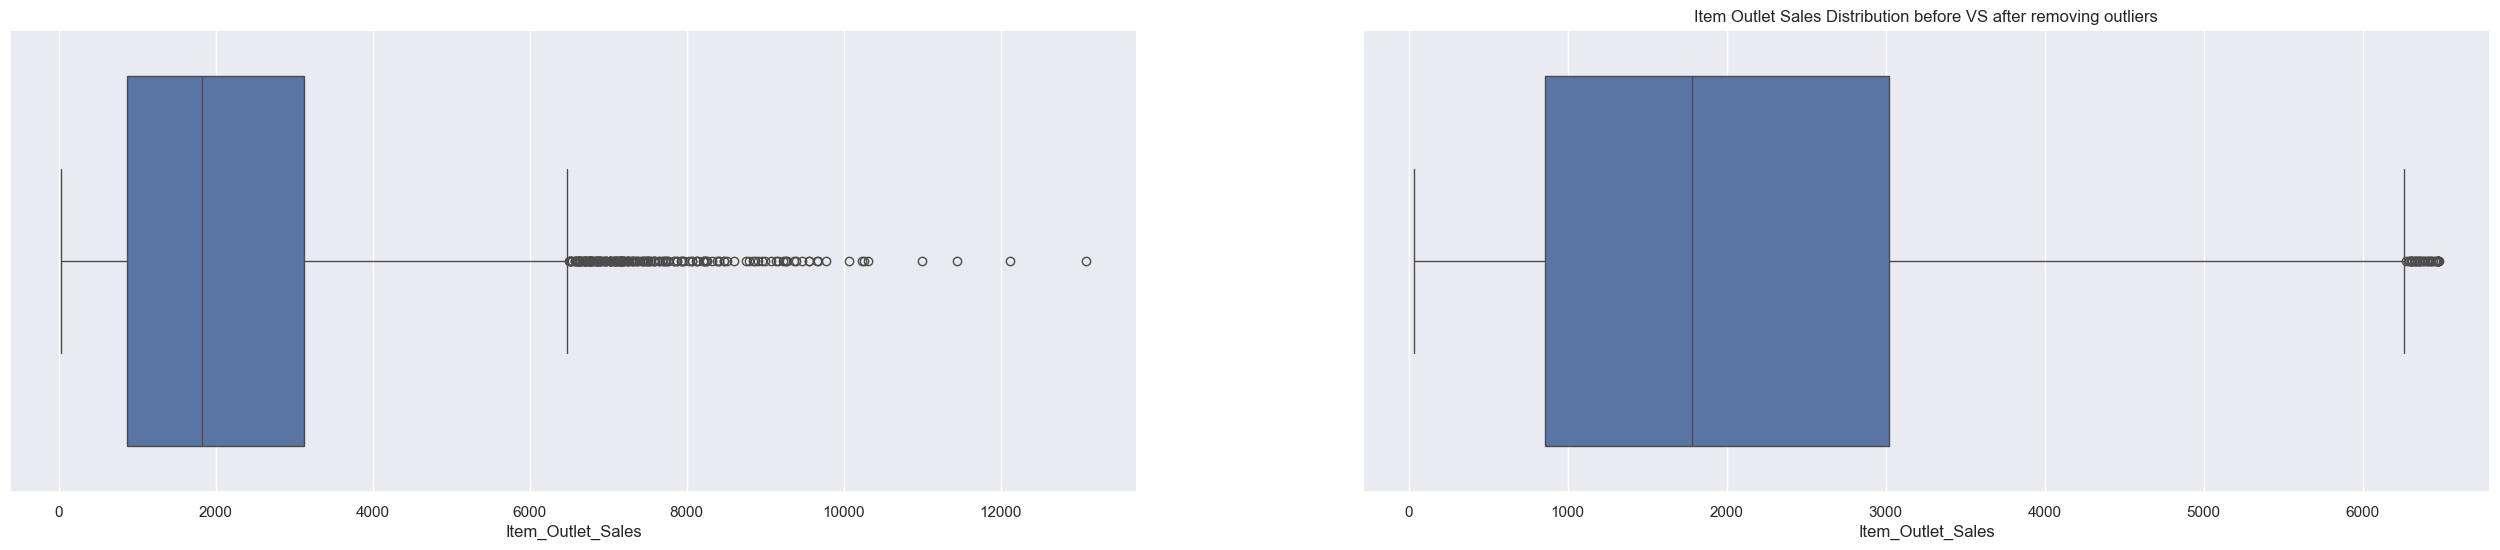

In [58]:
# detect outliers in the Item_Outlet_Sales feature
upper, lower = detect_outliers(train, "Item_Outlet_Sales")
print("Upper limit: ", upper)
print("Lower limit: ", lower)

_, ax = plt.subplots(nrows=1, ncols=2, figsize=(32, 6))
sns.boxplot(x=train['Item_Outlet_Sales'], ax=ax[0])

# removing outliers using the same function
train = train[(train['Item_Outlet_Sales'] > lower) & (train['Item_Outlet_Sales'] < upper)]

sns.boxplot(x=train['Item_Outlet_Sales'], ax=ax[1])
plt.title('Item Outlet Sales Distribution before VS after removing outliers')
plt.show()

# Label Encoder

In [59]:
encoder = LabelEncoder()

In [60]:
train['Item_Identifier']  = encoder.fit_transform(train['Item_Identifier'])
train['Item_Fat_Content']  = encoder.fit_transform(train['Item_Fat_Content'])
train['Item_Type']  = encoder.fit_transform(train['Item_Type'])
train['Outlet_Identifier']  = encoder.fit_transform(train['Outlet_Identifier'])
train['Outlet_Size']  = encoder.fit_transform(train['Outlet_Size'])
train['Outlet_Location_Type']  = encoder.fit_transform(train['Outlet_Location_Type'])
train['Outlet_Type']  = encoder.fit_transform(train['Outlet_Type'])

In [61]:
train.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,156,9.30,0,0.016047,4,249.8092,9,1999,1,0,1,3735.1380
1,8,5.92,1,0.019278,14,48.2692,3,2009,1,2,2,443.4228
2,662,17.50,0,0.016760,10,141.6180,9,1999,1,0,1,2097.2700
3,1121,19.20,1,0.000000,6,182.0950,0,1998,3,2,0,732.3800
4,1297,8.93,0,0.000000,9,53.8614,1,1987,0,2,1,994.7052


# PreProcessing Data

In [62]:
X = train.drop('Item_Outlet_Sales', axis=1)
y = train['Item_Outlet_Sales']

In [63]:
X.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,156,9.30,0,0.016047,4,249.8092,9,1999,1,0,1
1,8,5.92,1,0.019278,14,48.2692,3,2009,1,2,2
2,662,17.50,0,0.016760,10,141.6180,9,1999,1,0,1
3,1121,19.20,1,0.000000,6,182.0950,0,1998,3,2,0
4,1297,8.93,0,0.000000,9,53.8614,1,1987,0,2,1


In [64]:
y.head()

0    3735.1380
1     443.4228
2    2097.2700
3     732.3800
4     994.7052
Name: Item_Outlet_Sales, dtype: float64

In [65]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=101, test_size=0.2)

In [66]:
X.describe()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
count,8192.000000,8192.000000,8192.000000,8192.000000,8192.000000,8192.000000,8192.000000,8192.000000,8192.000000,8192.000000,8192.000000
mean,780.187744,12.863652,0.352051,0.063224,7.229980,139.111799,4.762817,1998.089844,1.732056,1.106567,1.201416
std,450.102233,4.267190,0.477639,0.046287,4.205454,61.536177,2.844914,8.287443,0.992639,0.808782,0.770255
min,0.000000,4.555000,0.000000,0.000000,0.000000,31.290000,0.000000,1985.000000,0.000000,0.000000,0.000000
25%,394.750000,9.300000,0.000000,0.026817,4.000000,93.027800,2.000000,1987.000000,1.000000,0.000000,1.000000
50%,783.500000,12.857370,0.000000,0.052735,6.000000,141.148300,5.000000,1999.000000,2.000000,1.000000,1.000000
75%,1168.000000,16.100000,1.000000,0.092790,10.000000,183.663400,7.000000,2004.000000,3.000000,2.000000,1.000000
max,1558.000000,21.350000,1.000000,0.195721,15.000000,266.888400,9.000000,2009.000000,3.000000,2.000000,3.000000


In [67]:
# Create a scaler instance
scaler = StandardScaler()

In [68]:
X_train_std = scaler.fit_transform(X_train)

In [69]:
X_train_std

array([[-0.2530511 ,  1.52242505, -0.73933292, ...,  1.27199331,
        -0.13788025, -0.2631656 ],
       [-1.28238654, -0.4632596 , -0.73933292, ..., -1.74551803,
         1.10152889, -0.2631656 ],
       [-1.5069284 ,  0.28944523, -0.73933292, ..., -0.73968092,
        -1.37728938, -0.2631656 ],
       ...,
       [ 0.60287578, -0.36814401, -0.73933292, ...,  0.2661562 ,
        -0.13788025, -0.2631656 ],
       [-0.4531379 ,  1.26408642, -0.73933292, ..., -1.74551803,
         1.10152889, -0.2631656 ],
       [ 1.19424345, -0.90830661, -0.73933292, ..., -0.73968092,
         1.10152889,  1.02861281]])

In [70]:
X_test_std = scaler.fit_transform(X_test)

In [71]:
X_test_std

array([[ 6.85898527e-01, -1.43127826e+00,  1.37315818e+00, ...,
        -7.28957605e-01,  1.11781520e+00,  1.07098502e+00],
       [ 1.28896426e+00,  2.16061017e-03, -7.28248221e-01, ...,
        -7.28957605e-01,  1.11781520e+00,  2.39677387e+00],
       [ 1.59936573e+00,  1.39498587e+00, -7.28248221e-01, ...,
         2.85271185e-01, -1.07669156e-01, -2.54803837e-01],
       ...,
       [ 2.51336457e-01, -1.78339916e+00,  1.37315818e+00, ...,
         1.29949997e+00, -1.07669156e-01, -2.54803837e-01],
       [-6.90953745e-01,  2.21249532e-01, -7.28248221e-01, ...,
         2.85271185e-01, -1.33315351e+00, -2.54803837e-01],
       [ 1.23131827e+00, -9.87350262e-01, -7.28248221e-01, ...,
        -7.28957605e-01,  1.11781520e+00,  1.07098502e+00]])

In [72]:
y_train

5412    3705.8428
1682    5536.7928
6138    1842.9344
7287     217.7166
5664    5086.7120
          ...    
5928     980.0576
8328    5518.1504
1417    2768.3964
1613    4288.4178
5158    1518.0240
Name: Item_Outlet_Sales, Length: 6553, dtype: float64

In [73]:
y_test

7743    1411.4960
400      717.7324
1801    2360.9268
4708     455.4072
4576    1955.4546
          ...    
8165    4327.7000
3984     591.8962
6005    1693.7952
5801    3179.8608
526      283.6308
Name: Item_Outlet_Sales, Length: 1639, dtype: float64

# ---------------------------------------------------------------------

# Train Part

# XGBoost

In [74]:
xg_model = XGBRegressor()
xg_model.fit(X_train_std, y_train)
xg_predictions = xg_model.predict(X_test_std)

# MAE
print('MAE', metrics.mean_absolute_error(y_test, xg_predictions))
# RMSE
print('RMSE', np.sqrt(mean_squared_error(y_test, xg_predictions)))
# MSE
print('MSE', metrics.mean_squared_error(y_test, xg_predictions))
# R2
print('R2', metrics.r2_score(y_test, xg_predictions))

MAE 802.6989703338093
RMSE 1099.7310454584906
MSE 1209408.3723452245
R2 0.45168705854427527


In [75]:
print('Training score  : {}'.format(xg_model.score(X_train_std, y_train)))
print('Test score      : {}'.format(xg_model.score(X_test_std, y_test)))

Training score  : 0.8660927103252094
Test score      : 0.45168705854427527


In [76]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8192 entries, 0 to 8521
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8192 non-null   int64  
 1   Item_Weight                8192 non-null   float64
 2   Item_Fat_Content           8192 non-null   int64  
 3   Item_Visibility            8192 non-null   float64
 4   Item_Type                  8192 non-null   int64  
 5   Item_MRP                   8192 non-null   float64
 6   Outlet_Identifier          8192 non-null   int64  
 7   Outlet_Establishment_Year  8192 non-null   int64  
 8   Outlet_Size                8192 non-null   int64  
 9   Outlet_Location_Type       8192 non-null   int64  
 10  Outlet_Type                8192 non-null   int64  
 11  Item_Outlet_Sales          8192 non-null   float64
dtypes: float64(4), int64(8)
memory usage: 832.0 KB


In [77]:
train.sample(4)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
8448,1058,14.30,0,0.123071,4,121.1730,3,2009,1,2,2,2093.9410
6400,951,16.35,0,0.034393,6,50.8324,0,1998,3,2,0,155.7972
1065,1545,16.75,0,0.126766,8,35.7532,0,1998,3,2,0,143.8128
1385,233,10.50,1,0.013551,13,142.0154,3,2009,1,2,2,2410.8618


# Linear Regression

In [78]:
lin_reg_model = LinearRegression()
lin_reg_model.fit(X_train_std, y_train)
# Predictions for LinearRegression on the test data
lin_reg_predictions = lin_reg_model.predict(X_test_std)

# MAE
print('MAE', metrics.mean_absolute_error(y_test, lin_reg_predictions))
# RMSE
print('RMSE', np.sqrt(mean_squared_error(y_test, lin_reg_predictions)))
# MSE
print('MSE', metrics.mean_squared_error(y_test, lin_reg_predictions))
# R2
print('R2', metrics.r2_score(y_test, lin_reg_predictions))

MAE 837.4934983137373
RMSE 1096.0970745959564
MSE 1201428.7969378135
R2 0.455304781526233


In [79]:
print('Training score  : {}'.format(lin_reg_model.score(X_train_std, y_train)))
print('Test score      : {}'.format(lin_reg_model.score(X_test_std, y_test)))

Training score  : 0.483573247160891
Test score      : 0.455304781526233


# RandomForest

In [80]:
rand_forest_model = RandomForestRegressor()
rand_forest_model.fit(X_train_std, y_train)
# Predictions for RandomForest on the test data
rand_forest_predictions = rand_forest_model.predict(X_test_std)

# MAE
print('MAE', metrics.mean_absolute_error(y_test, rand_forest_predictions))
# RMSE
print('RMSE', np.sqrt(mean_squared_error(y_test, rand_forest_predictions)))
# MSE
print('MSE', metrics.mean_squared_error(y_test, rand_forest_predictions))
# R2
print('R2', metrics.r2_score(y_test, rand_forest_predictions))

MAE 727.590123494814
RMSE 1016.1850023440156
MSE 1032631.9589889072
R2 0.5318326879311762


In [81]:
print('Training score  : {}'.format(rand_forest_model.score(X_train_std, y_train)))
print('Test score      : {}'.format(rand_forest_model.score(X_test_std, y_test)))

Training score  : 0.9349089929325229
Test score      : 0.5318326879311762


# Decision Tree

In [82]:
dest_model = DecisionTreeRegressor()
dest_model.fit(X_train_std, y_train)
# Predictions for Decision Tree on the test data
dest_predictions = dest_model.predict(X_test_std)

# MAE
print('MAE', metrics.mean_absolute_error(y_test, dest_predictions))
# RMSE
print('RMSE', np.sqrt(mean_squared_error(y_test, dest_predictions)))
# MSE
print('MSE', metrics.mean_squared_error(y_test, dest_predictions))
# R2
print('R2', metrics.r2_score(y_test, dest_predictions))

MAE 996.9146485661988
RMSE 1376.0285784347307
MSE 1893454.6486691057
R2 0.14155903691030647


In [83]:
print('Training score  : {}'.format(dest_model.score(X_train_std, y_train)))
print('Test score      : {}'.format(dest_model.score(X_test_std, y_test)))

Training score  : 1.0
Test score      : 0.14155903691030647


# Regularized linear regression

In [84]:
# Ridge Regression(L2 Regularization)
ridge_model = Ridge(alpha=1.0)  # Adjust alpha for more/less regularization
ridge_model.fit(X_train_std, y_train)
ridge_predictions = ridge_model.predict(X_test_std)

# MAE
print('MAE', metrics.mean_absolute_error(y_test, ridge_predictions))
# RMSE
print('RMSE', np.sqrt(mean_squared_error(y_test, ridge_predictions)))
# MSE
print('MSE', metrics.mean_squared_error(y_test, ridge_predictions))
# R2
print('R2', metrics.r2_score(y_test, ridge_predictions))

MAE 837.4824703345718
RMSE 1096.0898257815268
MSE 1201412.9061817776
R2 0.4553119859638598


In [85]:
print('Training score  : {}'.format(ridge_model.score(X_train_std, y_train)))
print('Test score      : {}'.format(ridge_model.score(X_test_std, y_test)))

Training score  : 0.4835732318889817
Test score      : 0.4553119859638598


In [86]:
# Lasso Regression (L1 Regularization)
lasso_model = Lasso(alpha=0.1)  # Adjust alpha for sparsity
lasso_model.fit(X_train_std, y_train)
lasso_predictions = lasso_model.predict(X_test_std)

# MAE
print('MAE', metrics.mean_absolute_error(y_test, lasso_predictions))
# RMSE
print('RMSE', np.sqrt(mean_squared_error(y_test, lasso_predictions)))
# MSE
print('MSE', metrics.mean_squared_error(y_test, lasso_predictions))
# R2
print('R2', metrics.r2_score(y_test, lasso_predictions))


MAE 837.4691672377049
RMSE 1096.0833053359727
MSE 1201398.6122362313
R2 0.45531846645093665


In [87]:
print('Training score  : {}'.format(lasso_model.score(X_train_std, y_train)))
print('Test score      : {}'.format(lasso_model.score(X_test_std, y_test)))

Training score  : 0.4835731819145198
Test score      : 0.45531846645093665


# AdaBoost 

In [88]:
ada_model= AdaBoostRegressor(n_estimators = 100)
ada_model.fit(X_train_std, y_train)

# predicting the test set results
ada_predictions = ada_model.predict(X_test_std)

# MAE
print('MAE', metrics.mean_absolute_error(y_test, ada_predictions))
# RMSE
print('RMSE', np.sqrt(mean_squared_error(y_test, ada_predictions)))
# MSE
print('MSE', metrics.mean_squared_error(y_test, ada_predictions))
# R2
print('R2', metrics.r2_score(y_test, ada_predictions))


MAE 749.1272332882581
RMSE 1015.0776660113464
MSE 1030382.6680350425
R2 0.5328524554202269


In [89]:
print('Training score  : {}'.format(ada_model.score(X_train_std, y_train)))
print('Test score      : {}'.format(ada_model.score(X_test_std, y_test)))

Training score  : 0.5455172032922413
Test score      : 0.5328524554202269


# ---------------------------------------------------------------

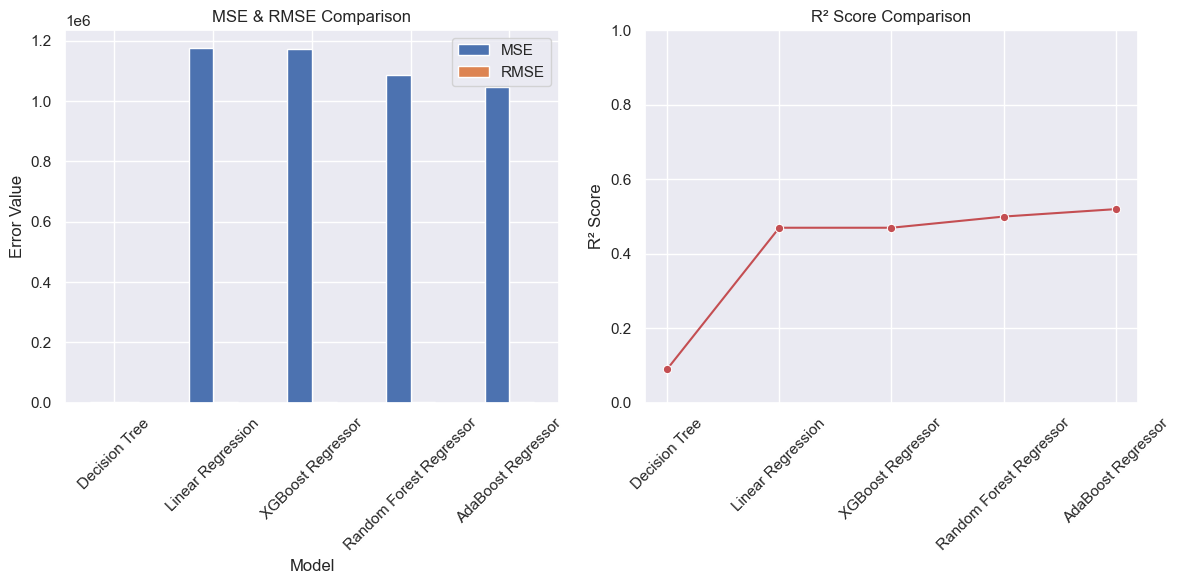

In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Model Performance Data
models = ["Decision Tree", "Linear Regression", "XGBoost Regression", "Random Forest Regression", "AdaBoost Regression", "Ridge Regression"]
mse = [1411.21, 1175983.29, 1174220.59, 1087289.94, 1048155.87]
rmse = [1411, 1084, 1083, 1042, 1023]
r2_score = [0.09, 0.47, 0.47, 0.50, 0.52]

# Creating DataFrame
performance_df = pd.DataFrame({
    "Model": models,
    "MSE": mse,
    "RMSE": rmse,
    "R² Score": r2_score
})

# Plotting
plt.figure(figsize=(12,6))

# Bar plot for MAE and RMSE
ax1 = plt.subplot(1, 2, 1)
performance_df.set_index("Model")[["MSE", "RMSE"]].plot(kind='bar', ax=ax1)
plt.title("MSE & RMSE Comparison")
plt.ylabel("Error Value")
plt.xticks(rotation=45)

# Line plot for R² Score
ax2 = plt.subplot(1, 2, 2)
sns.lineplot(x=models, y=r2_score, marker='o', color='r')
plt.title("R² Score Comparison")
plt.ylabel("R² Score")
plt.ylim(0, 1)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


# Test Part

In [91]:
#input1= (1,	19.35,	1,	0.039895,	14,	162.4868,	1,	0,	2,	1,	36)
input1 = (743,18.600,0,0.039356,5,246.3802,9,1999,1,0,1)
new_input = np.asanyarray(input1, dtype = float)
prediction = xg_model.predict(new_input.reshape(1, -1))
print(prediction)

# Find and print max and min predicted values
print(f"Sales Value is between {prediction-714.42} and {prediction+714.42}")

[2228.3381]
Sales Value is between [1513.9182] and [2942.758]


In [92]:
new_input = np.asarray(input1, dtype=float)
prediction = lin_reg_model.predict(new_input.reshape(1, -1))
print(prediction)

# Find and print max and min predicted values
print(f"Sales Value is between {prediction-714.42} and {prediction+714.42}")

[258685.4899392]
Sales Value is between [257971.0699392] and [259399.9099392]


In [93]:
new_input = np.asanyarray(input1, dtype = float)
predicted_value = rand_forest_model.predict(new_input.reshape(1, -1))
prediction = round(predicted_value[0], 1)
print(prediction)

# Find and print max and min predicted values
min_value = round(prediction - 714.42, 1)
max_value = round(prediction + 714.42, 1)
print(f"Sales Value is between {min_value} and {max_value}")

3544.2
Sales Value is between 2829.8 and 4258.6


In [94]:
new_input = np.asanyarray(input1, dtype = float)
prediction = dest_model.predict(new_input.reshape(1, -1))
print(prediction)

# Find and print max and min predicted values
print(f"Sales Value is between {prediction-714.42} and {prediction+714.42}")

[1561.9668]
Sales Value is between [847.5468] and [2276.3868]


In [95]:
new_input = np.asanyarray(input1, dtype = float)
prediction = lasso_model.predict(new_input.reshape(1, -1))
print(prediction)

# Find and print max and min predicted values
print(f"Sales Value is between {prediction-714.42} and {prediction+714.42}")

[258335.60648759]
Sales Value is between [257621.18648759] and [259050.02648759]


In [96]:
new_input = np.asanyarray(input1, dtype = float)
prediction = ada_model.predict(new_input.reshape(1, -1))
print(prediction)

# Find and print max and min predicted values
print(f"Sales Value is between {prediction-714.42} and {prediction+714.42}")

[3348.59942474]
Sales Value is between [2634.17942474] and [4063.01942474]


In [97]:
import pickle
pickle.dump(rand_forest_model, open('model.pkl', 'wb'))